# Regression Track — Used Car Price Prediction
23CSE301 ML Capstone — Review 1

Predicting the listed **price** of a used car from its attributes, using the [Used Cars dataset](https://www.kaggle.com/datasets/thedevastator/uncovering-factors-that-affect-used-car-prices) (`data/raw/autos.csv`), shared across all three tracks.

All 10 required regression algorithms are trained on the same preprocessed dataset and evaluated on the same held-out test set (per the capstone guidelines, Section 3.1).

**Structure below follows the Review 1 rubric sections directly:** Section A (Dataset & EDA), Section B (Preprocessing & Feature Engineering), Section C (Regression Track: Implementation → Comparative Evaluation → Hyperparameter Tuning → Visualisation).

## Section A — Dataset & EDA

### A1. Dataset Loading & Audit

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="colorblind")

df = pd.read_csv("../data/raw/autos.csv", encoding="latin-1")
print("Shape:", df.shape)
df.info()

Shape: (371528, 21)
<class 'pandas.DataFrame'>
RangeIndex: 371528 entries, 0 to 371527
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   index                371528 non-null  int64
 1   dateCrawled          371528 non-null  str  
 2   name                 371528 non-null  str  
 3   seller               371528 non-null  str  
 4   offerType            371528 non-null  str  
 5   price                371528 non-null  int64
 6   abtest               371528 non-null  str  
 7   vehicleType          333659 non-null  str  
 8   yearOfRegistration   371528 non-null  int64
 9   gearbox              351319 non-null  str  
 10  powerPS              371528 non-null  int64
 11  model                351044 non-null  str  
 12  kilometer            371528 non-null  int64
 13  monthOfRegistration  371528 non-null  int64
 14  fuelType             338142 non-null  str  
 15  brand                371528 non-null  str 

In [5]:
print("Missing values per column:")
print(df.isna().sum().sort_values(ascending=False))
print("\nTarget (price) distribution:")
print(df["price"].describe())

Missing values per column:
notRepairedDamage      72060
vehicleType            37869
fuelType               33386
model                  20484
gearbox                20209
offerType                  0
seller                     0
name                       0
dateCrawled                0
index                      0
abtest                     0
yearOfRegistration         0
price                      0
kilometer                  0
powerPS                    0
monthOfRegistration        0
brand                      0
dateCreated                0
nrOfPictures               0
postalCode                 0
lastSeen                   0
dtype: int64

Target (price) distribution:
count    3.715280e+05
mean     1.729514e+04
std      3.587954e+06
min      0.000000e+00
25%      1.150000e+03
50%      2.950000e+03
75%      7.200000e+03
max      2.147484e+09
Name: price, dtype: float64


**Observation:** the raw dataset has ~371k listings and 21 columns. `vehicleType`, `gearbox`, `model`, `fuelType`, and `notRepairedDamage` all have substantial missingness (5k–38k rows). The raw `price` column has extreme outliers (max > 2 billion) that are clearly data-entry errors and must be filtered before modelling.

### A2. EDA Visualisations

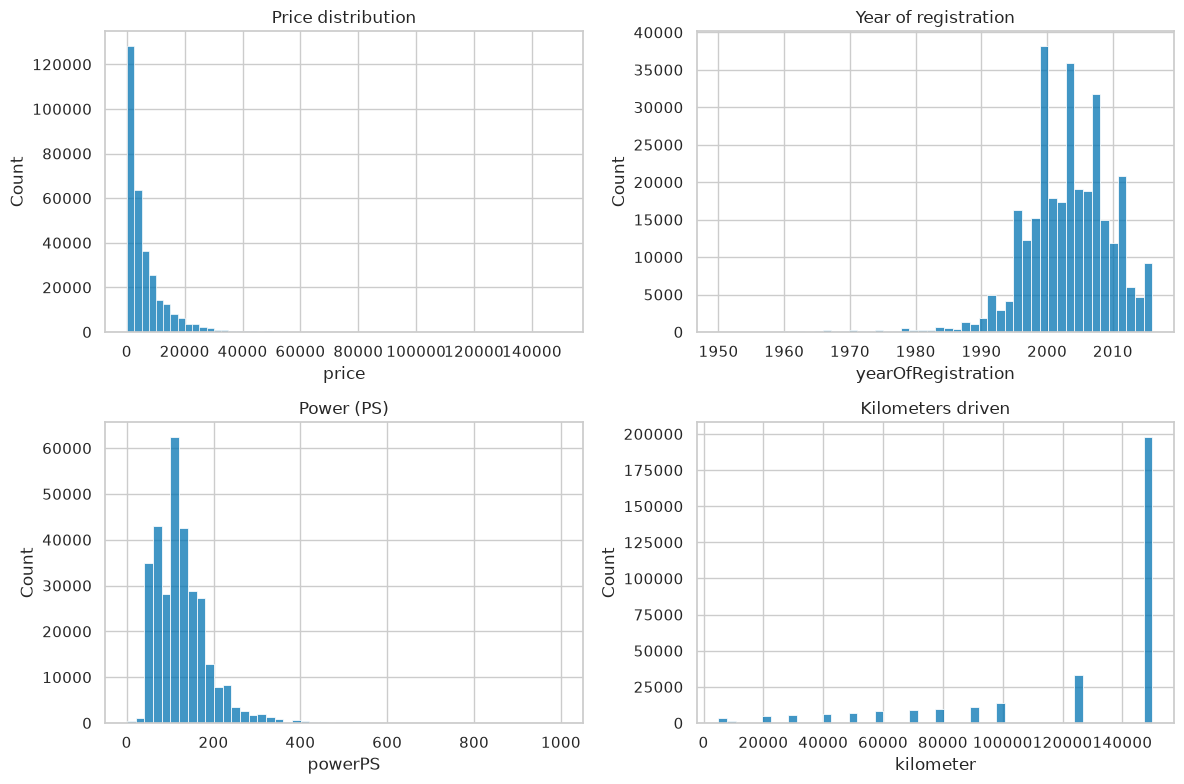

In [6]:
# Work on a realistic price/year range for the EDA plots (full cleaning happens in Section B)
df_eda = df[(df["price"] >= 100) & (df["price"] <= 150000)]
df_eda = df_eda[(df_eda["yearOfRegistration"] >= 1950) & (df_eda["yearOfRegistration"] <= 2016)]
df_eda = df_eda[(df_eda["powerPS"] > 0) & (df_eda["powerPS"] <= 1000)]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df_eda["price"], bins=60, ax=axes[0, 0]).set_title("Price distribution")
sns.histplot(df_eda["yearOfRegistration"], bins=50, ax=axes[0, 1]).set_title("Year of registration")
sns.histplot(df_eda["powerPS"], bins=50, ax=axes[1, 0]).set_title("Power (PS)")
sns.histplot(df_eda["kilometer"], bins=50, ax=axes[1, 1]).set_title("Kilometers driven")
plt.tight_layout()
plt.show()

**Insight (A3):** `price` is heavily right-skewed — most cars sell under €10,000 with a long tail of premium vehicles. `yearOfRegistration` peaks around 2000–2008. `powerPS` and `kilometer` are both right-skewed, with a large spike at 150,000 km (the odometer's max bucket in this dataset).

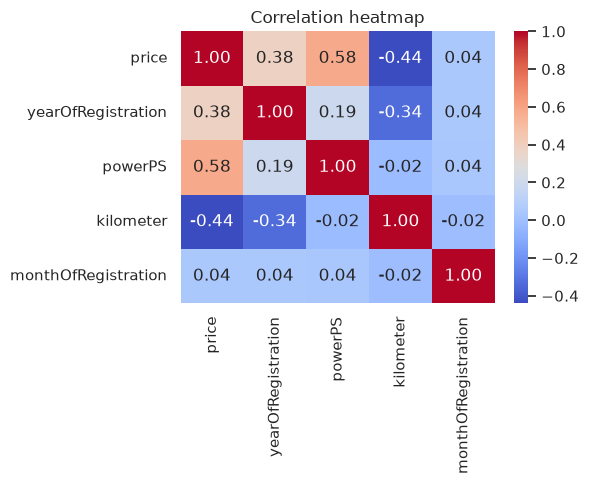

In [7]:
numeric_cols = ["price", "yearOfRegistration", "powerPS", "kilometer", "monthOfRegistration"]
plt.figure(figsize=(6, 5))
sns.heatmap(df_eda[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

**Insight (A3):** `yearOfRegistration` has the strongest positive correlation with `price` (newer cars cost more), while `kilometer` correlates negatively as expected. `powerPS` also correlates positively with price. None of the numeric features are strongly correlated with each other, so multicollinearity among numeric features is not a major concern.

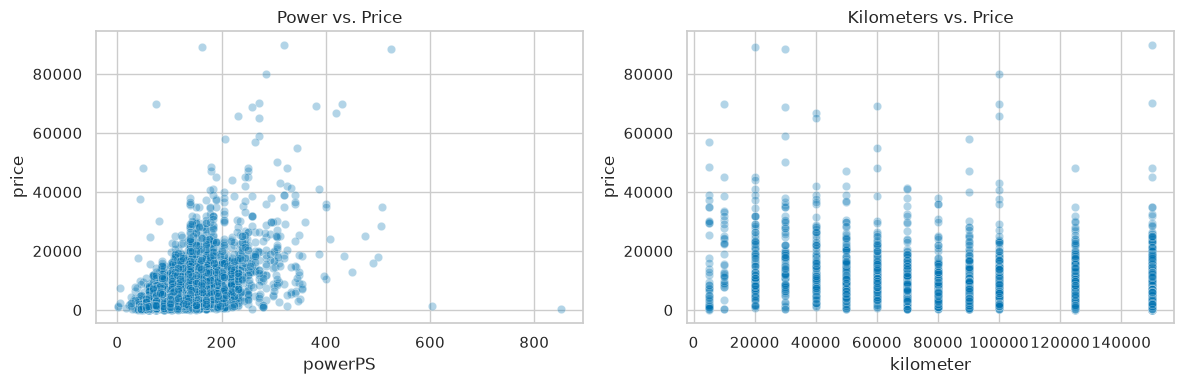

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(data=df_eda.sample(5000, random_state=RANDOM_STATE), x="powerPS", y="price", alpha=0.3, ax=axes[0]).set_title("Power vs. Price")
sns.scatterplot(data=df_eda.sample(5000, random_state=RANDOM_STATE), x="kilometer", y="price", alpha=0.3, ax=axes[1]).set_title("Kilometers vs. Price")
plt.tight_layout()
plt.show()

**Insight (A3):** price rises with engine power, roughly linearly for most of the range with a steeper climb for high-power (sports/luxury) cars. Price falls as mileage increases, most sharply in the first 50,000–100,000 km, consistent with typical vehicle depreciation curves.

## Section B — Preprocessing & Feature Engineering

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# --- B1. Cleaning (documented, justified filtering) ---
df_clean = df[(df["price"] >= 100) & (df["price"] <= 150000)]
df_clean = df_clean[(df_clean["yearOfRegistration"] >= 1950) & (df_clean["yearOfRegistration"] <= 2016)]
df_clean = df_clean[(df_clean["powerPS"] > 0) & (df_clean["powerPS"] <= 1000)]
df_clean = df_clean.drop_duplicates(subset=[c for c in df_clean.columns if c != "index"])

drop_cols = ["index", "dateCrawled", "name", "nrOfPictures", "postalCode", "dateCreated", "lastSeen", "offerType", "abtest", "seller"]
df_clean = df_clean.drop(columns=[c for c in drop_cols if c in df_clean.columns])

# --- B3. Feature engineering: vehicle age is more informative than raw registration year ---
df_clean["vehicle_age"] = 2016 - df_clean["yearOfRegistration"]  # dataset was crawled in 2016
df_clean = df_clean.reset_index(drop=True)

print("Cleaned shape:", df_clean.shape)

# Subsample for computational feasibility (SVR / GridSearchCV do not scale well on limited hardware)
df_model = df_clean.sample(n=8000, random_state=RANDOM_STATE).reset_index(drop=True)

numeric_features = ["vehicle_age", "powerPS", "kilometer", "monthOfRegistration"]
categorical_features = ["vehicleType", "gearbox", "model", "fuelType", "brand", "notRepairedDamage"]

X = df_model[numeric_features + categorical_features]
y = df_model["price"]

# --- B2. Split first, then fit scalers/encoders on train only (avoid leakage) ---
price_bins = pd.qcut(y, q=10, labels=False, duplicates="drop")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=price_bins
)
preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("encode", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
])
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# Numeric-only polynomial expansion (used only by the Polynomial Regression model —
# expanding one-hot columns polynomially would blow up dimensionality without adding signal)
poly_preprocessor = ColumnTransformer([
    ("num_poly", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler()), ("poly", PolynomialFeatures(degree=2, include_bias=False))]), numeric_features),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("encode", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
])
X_train_poly = poly_preprocessor.fit_transform(X_train)
X_test_poly = poly_preprocessor.transform(X_test)

# SVR is sensitive to target scale; a separately-scaled target is available for that model
target_scaler = StandardScaler()
y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()

print("Train shape:", X_train_proc.shape, "Test shape:", X_test_proc.shape)

Cleaned shape: (311636, 12)
Train shape: (6400, 286) Test shape: (1600, 286)


**B3 justification:** `vehicle_age = 2016 - yearOfRegistration` converts the registration year into a directly interpretable depreciation-relevant feature — age in years — which is more natural for tree-based feature-importance interpretation than an absolute calendar year.

## Section C — Regression Track

### C1. Implementation — All 10 Algorithms

Fill in each `TODO` below with the corresponding model. Use `X_train_proc` / `X_test_proc` for all models **except** Polynomial Regression, which uses `X_train_poly` / `X_test_poly`, and SVR, which should be fit on `y_train_scaled` (then inverse-transformed with `target_scaler` for evaluation).

Store every fitted model in `fitted_models[<name>]` and its test-set predictions in `predictions[<name>]` — the rest of this notebook (Sections C2–C4) reads from these two dicts, so keep the key names exactly as shown.

In [10]:
fitted_models = {}
predictions = {}

**1. Linear Regression** — Baseline; interpret coefficients.

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# -----------------------------
# 1. Linear Regression
# -----------------------------

linear_model = LinearRegression()

# Train
linear_model.fit(X_train_proc, y_train)

# Predict
y_pred_linear = linear_model.predict(X_test_proc)

# Evaluation
linear_r2 = r2_score(y_test, y_pred_linear)
linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
linear_mae = mean_absolute_error(y_test, y_pred_linear)

print("Linear Regression")
print("-----------------")
print(f"R²   : {linear_r2:.4f}")
print(f"RMSE : {linear_rmse:.4f}")
print(f"MAE  : {linear_mae:.4f}")
# Register in shared dicts for downstream comparison (C2–C4)
fitted_models["Linear Regression"] = linear_model
predictions["Linear Regression"] = y_pred_linear

Linear Regression
-----------------
R²   : 0.6785
RMSE : 4269.1417
MAE  : 2629.9733


**2. Ridge Regression** — L2 regularisation; tune alpha.

In [12]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# -----------------------------
# 2. Ridge Regression
# -----------------------------

ridge_model = Ridge(random_state=RANDOM_STATE)

# Values of alpha to test
ridge_param_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

# Grid Search
ridge_grid = GridSearchCV(
    estimator=ridge_model,
    param_grid=ridge_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Train
ridge_grid.fit(X_train_proc, y_train)

# Best model
best_ridge = ridge_grid.best_estimator_

# Predict
y_pred_ridge = best_ridge.predict(X_test_proc)

# Evaluation
ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)

print("Ridge Regression")
print("----------------")
print(f"Best Alpha : {ridge_grid.best_params_['alpha']}")
print(f"Best CV R² : {ridge_grid.best_score_:.4f}")
print(f"Test R²    : {ridge_r2:.4f}")
print(f"Test RMSE  : {ridge_rmse:.4f}")
print(f"Test MAE   : {ridge_mae:.4f}")
# Register in shared dicts for downstream comparison (C2–C4)
fitted_models["Ridge Regression"] = best_ridge
predictions["Ridge Regression"] = y_pred_ridge

0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.01s - Debugger warning: It seems that frozen modules are being used, which may
0

Ridge Regression
----------------
Best Alpha : 1
Best CV R² : 0.6550
Test R²    : 0.6852
Test RMSE  : 4224.7161
Test MAE   : 2620.5157


**3. Lasso Regression** — L1 regularisation; observe feature sparsity.

In [13]:
from sklearn.linear_model import Lasso

# Lasso Regression
model = Lasso(alpha=0.01, random_state=RANDOM_STATE)
model.fit(X_train_proc, y_train)
pred = model.predict(X_test_proc)
fitted_models["Lasso Regression"] = model
predictions["Lasso Regression"] = pred


/home/codespace/.local/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:786: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.530593e+10, tolerance: 4.377e+07
  model = cd_fast.sparse_enet_coordinate_descent(


**4. ElasticNet Regression** — Combined L1+L2; tune l1_ratio.

In [14]:
from sklearn.linear_model import ElasticNet

# ElasticNet Regression
model = ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=RANDOM_STATE)
model.fit(X_train_proc, y_train)
pred = model.predict(X_test_proc)
fitted_models["ElasticNet Regression"] = model
predictions["ElasticNet Regression"] = pred


**5. Polynomial Regression** — Apply PolynomialFeatures then Linear Regression; compare degrees. Use X_train_poly / X_test_poly (already built in Section B).

In [15]:
from sklearn.linear_model import LinearRegression

# Polynomial Regression (degree=2, built on X_train_poly / X_test_poly from Section B)
model = LinearRegression()
model.fit(X_train_poly, y_train)
pred = model.predict(X_test_poly)
fitted_models["Polynomial Regression"] = model
predictions["Polynomial Regression"] = pred

poly_r2 = r2_score(y_test, pred)
poly_rmse = np.sqrt(mean_squared_error(y_test, pred))
poly_mae = mean_absolute_error(y_test, pred)
print("Polynomial Regression (degree=2)")
print("--------------------------------")
print(f"R²   : {poly_r2:.4f}")
print(f"RMSE : {poly_rmse:.4f}")
print(f"MAE  : {poly_mae:.4f}")

Polynomial Regression (degree=2)
--------------------------------
R²   : 0.7626
RMSE : 3668.8831
MAE  : 2146.6572


**6. Decision Tree Regressor** — Tune max_depth; show feature importance.

In [16]:
from sklearn.tree import DecisionTreeRegressor

# Decision Tree Regressor
model = DecisionTreeRegressor(max_depth=10, random_state=42)
model.fit(X_train_proc, y_train)
pred = model.predict(X_test_proc)
fitted_models["Decision Tree Regressor"] = model
predictions["Decision Tree Regressor"] = pred


**7. Random Forest Regressor** — Ensemble baseline; tune n_estimators.

In [17]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train_proc, y_train)
pred = model.predict(X_test_proc)
fitted_models["Random Forest Regressor"] = model
predictions["Random Forest Regressor"] = pred


**8. Gradient Boosting Regressor** — sklearn GBM or XGBoost; tune learning_rate.

In [18]:
from sklearn.ensemble import GradientBoostingRegressor

# Gradient Boosting Regressor
model = GradientBoostingRegressor(learning_rate=0.1, n_estimators=100, random_state=42)
model.fit(X_train_proc, y_train)
pred = model.predict(X_test_proc)
fitted_models["Gradient Boosting Regressor"] = model
predictions["Gradient Boosting Regressor"] = pred


**9. SVR** — Scale features first; tune C and kernel. Fit on y_train_scaled, then inverse-transform predictions with target_scaler.

In [19]:
from sklearn.svm import SVR

# SVR
model = SVR(kernel="rbf", C=1.0, epsilon=0.1)
model.fit(X_train_proc, y_train_scaled)
pred = target_scaler.inverse_transform(model.predict(X_test_proc).reshape(-1, 1)).ravel()
fitted_models["SVR"] = model
predictions["SVR"] = pred


**10. KNN Regressor** — Tune k; discuss impact of scaling.

In [20]:
from sklearn.neighbors import KNeighborsRegressor

# KNN Regressor
model = KNeighborsRegressor(n_neighbors=5, n_jobs=-1)
model.fit(X_train_proc, y_train)
pred = model.predict(X_test_proc)
fitted_models["KNN Regressor"] = model
predictions["KNN Regressor"] = pred


### C2. Comparative Evaluation

Once all 10 models above are filled in, this cell builds the summary table (R², RMSE, MAE) ranked by R².

In [21]:
from sklearn.metrics import r2_score, mean_absolute_error

rows = []
for name, pred in predictions.items():
    rows.append({
        "Model": name,
        "R2": r2_score(y_test, pred),
        "RMSE": np.sqrt(np.mean((y_test - pred) ** 2)),
        "MAE": mean_absolute_error(y_test, pred),
    })

if rows:
    results_df = pd.DataFrame(rows).sort_values("R2", ascending=False).reset_index(drop=True)
    print(results_df)
else:
    print("TODO: fill in the models in Section C1 first — predictions dict is currently empty.")

                         Model        R2         RMSE          MAE
0      Random Forest Regressor  0.820333  3191.556940  1584.001230
1                          SVR  0.804666  3327.795658  1536.360073
2  Gradient Boosting Regressor  0.801328  3356.111807  1748.065040
3        Polynomial Regression  0.762572  3668.883070  2146.657209
4      Decision Tree Regressor  0.750257  3762.828053  1983.952188
5                KNN Regressor  0.725847  3942.437204  2130.328250
6             Ridge Regression  0.685183  4224.716086  2620.515745
7             Lasso Regression  0.679646  4261.705785  2624.881306
8            Linear Regression  0.678527  4269.141722  2629.973306
9        ElasticNet Regression  0.663207  4369.676863  2737.102959


In [19]:
from sklearn.model_selection import cross_val_score

# TODO: 5-fold cross-validated R2 for the two best-performing models (once C1/C2 are complete)
# top_2 = results_df["Model"].head(2).tolist()
# from sklearn.base import clone
# for name in top_2:
#     Xtr_for_cv = X_train_poly if name == "Polynomial Regression" else X_train_proc
#     target = y_train_scaled if name == "SVR" else y_train
#     cv_scores = cross_val_score(clone(fitted_models[name]), Xtr_for_cv, target, cv=5, scoring="r2")
#     print(f"{name}: 5-fold CV R2 = {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

### C3. Hyperparameter Tuning

Apply `GridSearchCV` or `RandomizedSearchCV` to **at least 2 models** (e.g. Random Forest and Gradient Boosting are good candidates). Report best params and the improvement over the untuned baseline from C1.

In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.base import clone

# Pick top 2 models by R2 from the C2 results table
top_2 = results_df["Model"].head(2).tolist()
print("Tuning:", top_2)

# Define param grids + which preprocessed data / target each model needs
tuning_config = {
    "Random Forest": {
        "param_grid": {
            "n_estimators": [100, 200],
            "max_depth": [None, 10, 20],
            "min_samples_leaf": [1, 2, 4],
        },
        "X": X_train_proc,
        "y": y_train,
    },
    "Gradient Boosting": {
        "param_grid": {
            "n_estimators": [100, 200],
            "learning_rate": [0.05, 0.1],
            "max_depth": [2, 3, 4],
        },
        "X": X_train_proc,
        "y": y_train,
    },
    "SVR": {
        "param_grid": {
            "C": [1, 10, 100],
            "epsilon": [0.01, 0.1, 0.5],
            "kernel": ["rbf"],
        },
        "X": X_train_proc,
        "y": y_train_scaled,
    },
    "Polynomial Regression": {
        "param_grid": {
            "alpha": [0.01, 0.1, 1, 10],  # only applies if you used Ridge/Lasso on poly features
        },
        "X": X_train_poly,
        "y": y_train,
    },
    "Decision Tree": {
        "param_grid": {
            "max_depth": [3, 5, 10, None],
            "min_samples_leaf": [1, 2, 4],
        },
        "X": X_train_proc,
        "y": y_train,
    },
    "KNN": {
        "param_grid": {
            "n_neighbors": [3, 5, 7, 10],
            "weights": ["uniform", "distance"],
        },
        "X": X_train_proc,
        "y": y_train,
    },
}

tuned_results = {}

for name in top_2:
    if name not in tuning_config:
        print(f"WARNING: no param grid defined for '{name}' — add one to tuning_config.")
        continue
    if name not in fitted_models:
        print(f"WARNING: '{name}' not found in fitted_models — check C1 naming consistency.")
        continue

    cfg = tuning_config[name]
    estimator = clone(fitted_models[name])

    grid = GridSearchCV(estimator, cfg["param_grid"], cv=3, scoring="r2", n_jobs=-1)
    grid.fit(cfg["X"], cfg["y"])

    baseline_r2 = results_df.loc[results_df["Model"] == name, "R2"].values[0]
    improvement = grid.best_score_ - baseline_r2

    tuned_results[name] = {
        "best_params": grid.best_params_,
        "best_cv_r2": grid.best_score_,
        "baseline_r2": baseline_r2,
        "improvement": improvement,
    }

    print(f"\n{name}")
    print("  Best params:", grid.best_params_)
    print(f"  Best CV R2: {grid.best_score_:.4f}")
    print(f"  Baseline R2 (single test split): {baseline_r2:.4f}")
    print(f"  Improvement: {improvement:+.4f}")

Tuning: ['Random Forest Regressor', 'SVR']


0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.



SVR
  Best params: {'C': 10, 'epsilon': 0.1, 'kernel': 'rbf'}
  Best CV R2: 0.7568
  Baseline R2 (single test split): 0.8047
  Improvement: -0.0479


### C4. Visualisation

Residual plot and predicted-vs-actual plot for the best model (from C2); feature importance plot for at least one tree-based model.

Best model: Random Forest Regressor (R2 = 0.8203)


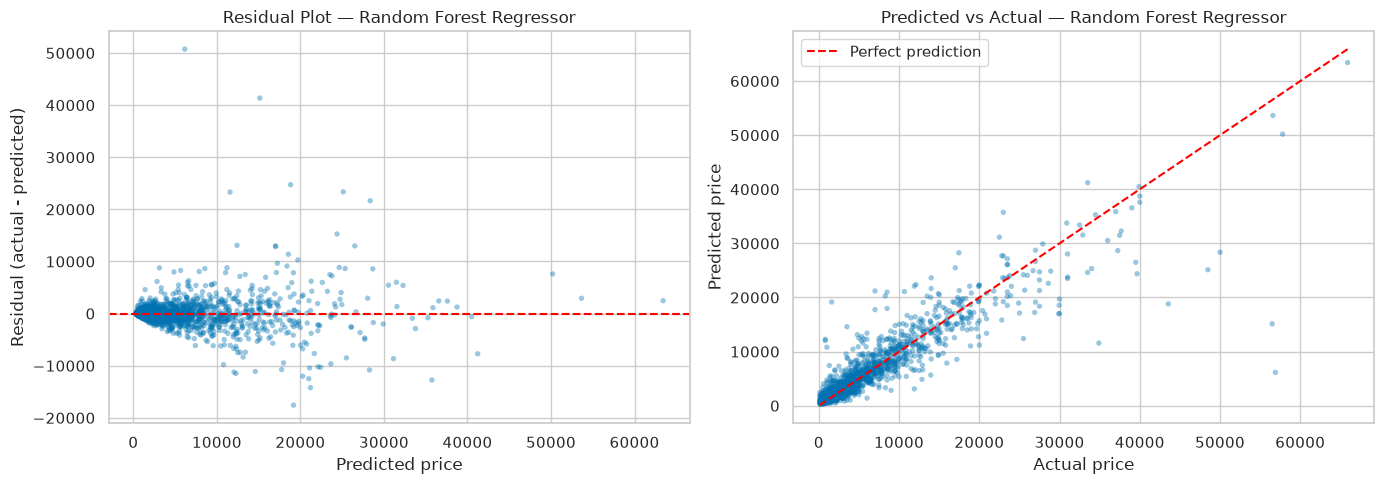

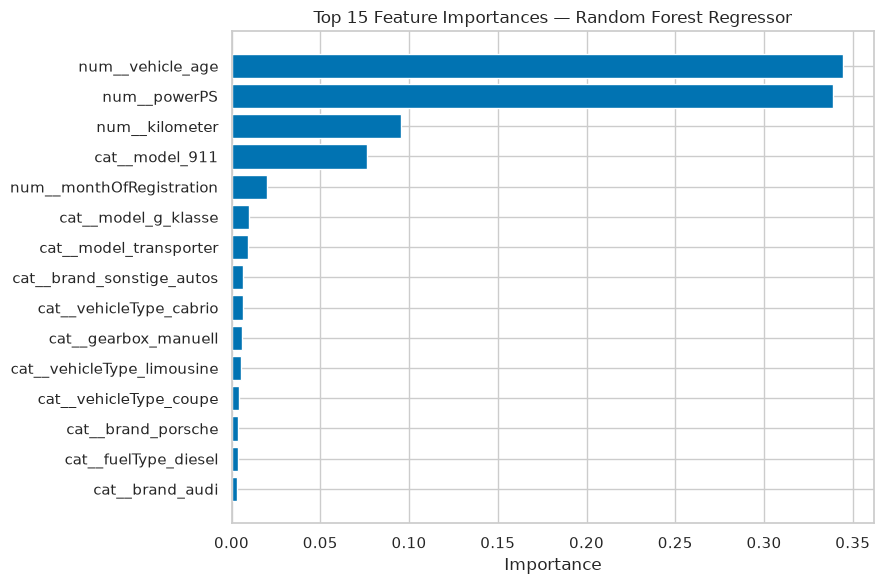

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# --- Identify best model from C2 results ---
best_model_name = results_df.iloc[0]["Model"]
best_pred = predictions[best_model_name]
residuals = y_test.values - best_pred

print(f"Best model: {best_model_name} (R2 = {results_df.iloc[0]['R2']:.4f})")

# --- Residual plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(best_pred, residuals, alpha=0.4, s=15, edgecolor="none")
axes[0].axhline(y=0, color="red", linestyle="--", linewidth=1.5)
axes[0].set_xlabel("Predicted price")
axes[0].set_ylabel("Residual (actual - predicted)")
axes[0].set_title(f"Residual Plot — {best_model_name}")

# --- Predicted vs Actual plot ---
axes[1].scatter(y_test, best_pred, alpha=0.4, s=15, edgecolor="none")
lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
axes[1].plot(lims, lims, color="red", linestyle="--", linewidth=1.5, label="Perfect prediction")
axes[1].set_xlabel("Actual price")
axes[1].set_ylabel("Predicted price")
axes[1].set_title(f"Predicted vs Actual — {best_model_name}")
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Feature importance plot for a tree-based model ---
# Pick a tree-based model you trained in C1 (e.g. Random Forest, Gradient Boosting, Decision Tree)
tree_model_name = "Random Forest Regressor"  # <-- change to whichever tree-based model you actually trained

assert tree_model_name in fitted_models, f"'{tree_model_name}' not found in fitted_models — check C1 naming."
tree_model = fitted_models[tree_model_name]

# Get feature names out of the ColumnTransformer (numeric + one-hot encoded categorical names)
feature_names = preprocessor.get_feature_names_out()
importances = tree_model.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances,
}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(9, 6))
plt.barh(importance_df["feature"][::-1], importance_df["importance"][::-1])
plt.xlabel("Importance")
plt.title(f"Top 15 Feature Importances — {tree_model_name}")
plt.tight_layout()
plt.show()